# **Hungary GP 2025**
## Tyre and Stint Analysis


In [108]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot
import configuration.config as DATA
import Sliplib.Gotyres as GT

importlib.reload(slipclassify)
importlib.reload(slplot)
importlib.reload(grid_sum)
importlib.reload(GT)

<module 'Sliplib.Gotyres' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Hungary_GP/notebooks/../../Sliplib/Gotyres.py'>

In [109]:
# Load Race Session
R_session = sl.load_gp(2025,"Hungarian Grand Prix","R")
R_session.load()

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '14', '5', '18', '30', '1', '12', '6', '44', '27', '55', '23', '31', '22', '43', '10', '87']


### Load Lap Data

In [110]:
# Extract Lap Data
R_Laps = R_session.laps
R_Laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:59:18.340000,NOR,4,0 days 00:01:30.120000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.396000,...,True,McLaren,0 days 00:57:47.946000,2025-08-03 13:03:06.040,1,5.0,False,,False,False
1,0 days 01:00:42.304000,NOR,4,0 days 00:01:23.964000,2.0,1.0,NaT,NaT,0 days 00:00:30.209000,0 days 00:00:30.346000,...,True,McLaren,0 days 00:59:18.340000,2025-08-03 13:04:36.434,1,5.0,False,,False,True
2,0 days 01:02:05.527000,NOR,4,0 days 00:01:23.223000,3.0,1.0,NaT,NaT,0 days 00:00:29.792000,0 days 00:00:30.097000,...,True,McLaren,0 days 01:00:42.304000,2025-08-03 13:06:00.398,1,4.0,False,,False,True
3,0 days 01:03:28.404000,NOR,4,0 days 00:01:22.877000,4.0,1.0,NaT,NaT,0 days 00:00:30.125000,0 days 00:00:29.665000,...,True,McLaren,0 days 01:02:05.527000,2025-08-03 13:07:23.621,1,4.0,False,,False,True
4,0 days 01:04:51.043000,NOR,4,0 days 00:01:22.639000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:29.672000,...,True,McLaren,0 days 01:03:28.404000,2025-08-03 13:08:46.498,1,4.0,False,,False,True


### Stint Overview
Get the Stint breakdown (compound, laps run, freshness) for the entire grid

In [111]:
# Get the Stint of all drivers
grid_stint = grid_sum.get_stint(R_Laps)
grid_stint

,Driver,Total Stint,Pit Stops
0,NOR,2,1
1,STR,2,1
2,BOR,2,1
3,ALO,2,1
4,LAW,2,1
5,HAM,2,1
6,HAD,2,1
7,ANT,2,1
8,OCO,2,1
9,BEA,2,1


In [112]:
# Extract Data
grid_stint.to_csv("../data/Race_Stint_Summary.csv",index=False)

### Insights
- *(Fill in after reviewing grid_stint: who ran a 1-stop vs 2-stop? Any outlier strategies?)*

## Driver Tyre Analysis
From the Result and Lap Analysis notebook, the drivers under focus are:
- Nico Hulkenberg
- Esteban Ocon
- Lando Norris
- Oscar Piastri
- Charles Leclerc
- Lewis Hamilton

In [113]:
# Import Drivers
top_drivers = slipclassify.select_drivers(R_Laps,DATA.CONTENDERS)

# Test
top_drivers["HAD"]

dict_keys(['HAD', 'HUL', 'ALB', 'COL', 'NOR', 'LAW', 'BEA', 'SAI', 'OCO', 'GAS', 'PIA', 'VER'])


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
699,0 days 00:59:21.697000,HAD,6,0 days 00:01:33.477000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.391000,...,True,Racing Bulls,0 days 00:57:47.946000,2025-08-03 13:03:06.040,1,11.0,False,,False,False
700,0 days 01:00:46.670000,HAD,6,0 days 00:01:24.973000,2.0,1.0,NaT,NaT,0 days 00:00:30.465000,0 days 00:00:30.827000,...,True,Racing Bulls,0 days 00:59:21.697000,2025-08-03 13:04:39.791,1,11.0,False,,False,True
701,0 days 01:02:10.686000,HAD,6,0 days 00:01:24.016000,3.0,1.0,NaT,NaT,0 days 00:00:29.756000,0 days 00:00:30.642000,...,True,Racing Bulls,0 days 01:00:46.670000,2025-08-03 13:06:04.764,1,11.0,False,,False,True
702,0 days 01:03:34.926000,HAD,6,0 days 00:01:24.240000,4.0,1.0,NaT,NaT,0 days 00:00:29.841000,0 days 00:00:30.744000,...,True,Racing Bulls,0 days 01:02:10.686000,2025-08-03 13:07:28.780,1,11.0,False,,False,True
703,0 days 01:04:58.898000,HAD,6,0 days 00:01:23.972000,5.0,1.0,NaT,NaT,0 days 00:00:29.913000,0 days 00:00:30.386000,...,True,Racing Bulls,0 days 01:03:34.926000,2025-08-03 13:08:53.020,1,11.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,0 days 02:27:50.050000,HAD,6,0 days 00:01:24.452000,65.0,2.0,NaT,NaT,0 days 00:00:31.705000,0 days 00:00:29.538000,...,True,Racing Bulls,0 days 02:26:25.598000,2025-08-03 14:31:43.692,1,11.0,False,,False,True
764,0 days 02:29:11.628000,HAD,6,0 days 00:01:21.578000,66.0,2.0,NaT,NaT,0 days 00:00:29.176000,0 days 00:00:29.277000,...,True,Racing Bulls,0 days 02:27:50.050000,2025-08-03 14:33:08.144,1,11.0,False,,False,True
765,0 days 02:30:33.133000,HAD,6,0 days 00:01:21.505000,67.0,2.0,NaT,NaT,0 days 00:00:29.404000,0 days 00:00:29.032000,...,True,Racing Bulls,0 days 02:29:11.628000,2025-08-03 14:34:29.722,1,11.0,False,,False,True
766,0 days 02:31:56.327000,HAD,6,0 days 00:01:23.194000,68.0,2.0,NaT,NaT,0 days 00:00:29.655000,0 days 00:00:30.215000,...,True,Racing Bulls,0 days 02:30:33.133000,2025-08-03 14:35:51.227,1,11.0,False,,False,True


### Tyre Data per Driver

In [114]:
# Get Tyre Data for each driver
Drivers_Tyre_Data = slipclassify.pick_tyre_data(top_drivers)
# Test
Drivers_Tyre_Data["PIA"]

,Driver,LapNumber,Compound,TyreLife,FreshTyre,Stint
70,PIA,1.0,MEDIUM,1.0,True,1.0
71,PIA,2.0,MEDIUM,2.0,True,1.0
72,PIA,3.0,MEDIUM,3.0,True,1.0
73,PIA,4.0,MEDIUM,4.0,True,1.0
74,PIA,5.0,MEDIUM,5.0,True,1.0
...,...,...,...,...,...,...
135,PIA,66.0,HARD,21.0,True,3.0
136,PIA,67.0,HARD,22.0,True,3.0
137,PIA,68.0,HARD,23.0,True,3.0
138,PIA,69.0,HARD,24.0,True,3.0


### Stint Breakdown (Compound, Lap Range, Freshness)

In [115]:
# Stint Breakdown
GT.stint_breakdown(Drivers_Tyre_Data)

--- HAD ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  33.0   MEDIUM      True
2.0        34.0  69.0     HARD      True

--- HUL ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0   5.0     SOFT      True
2.0         6.0  41.0   MEDIUM      True
3.0        42.0  69.0   MEDIUM      True

--- ALB ---


...

LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  32.0     HARD      True
2.0        33.0  69.0   MEDIUM      True

--- PIA ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  18.0   MEDIUM      True
2.0        19.0  45.0     HARD     False
3.0        46.0  70.0     HARD      True

--- VER ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  17.0   MEDIUM      True
2.0        18.0  48.0     HARD      True
3.0        49.0  70.0     HARD      True

### Insights
- *(Fill in: who pitted early/late, undercut vs overcut attempts, compound choices)*

## Tyre Degradation

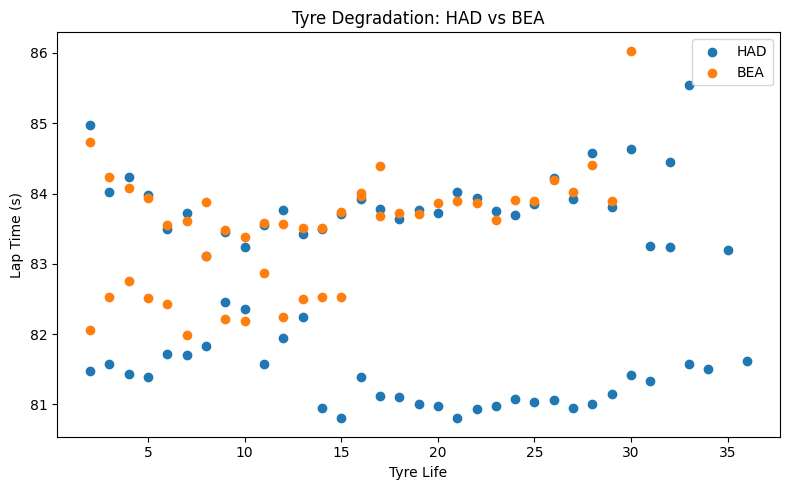

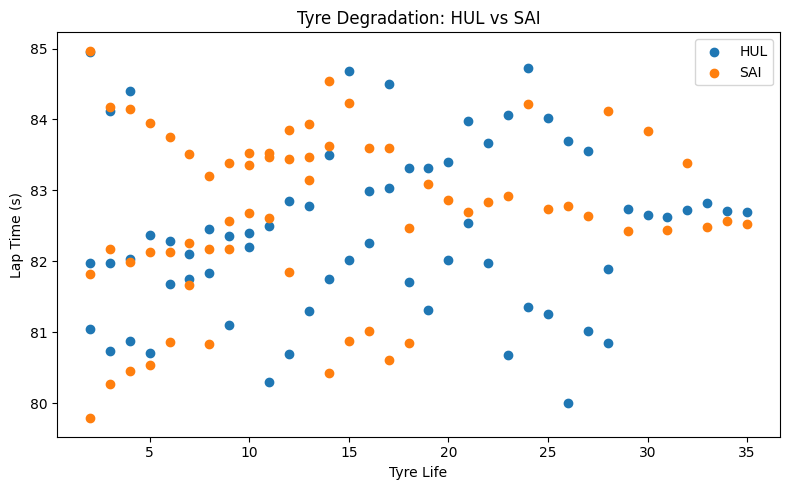

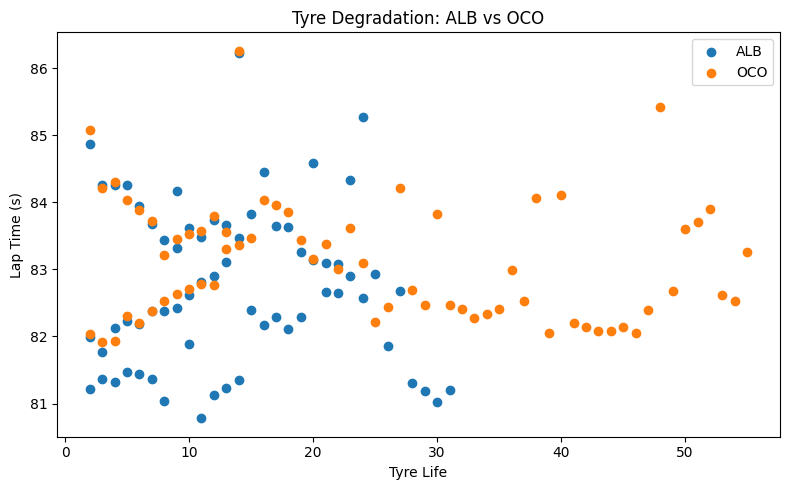

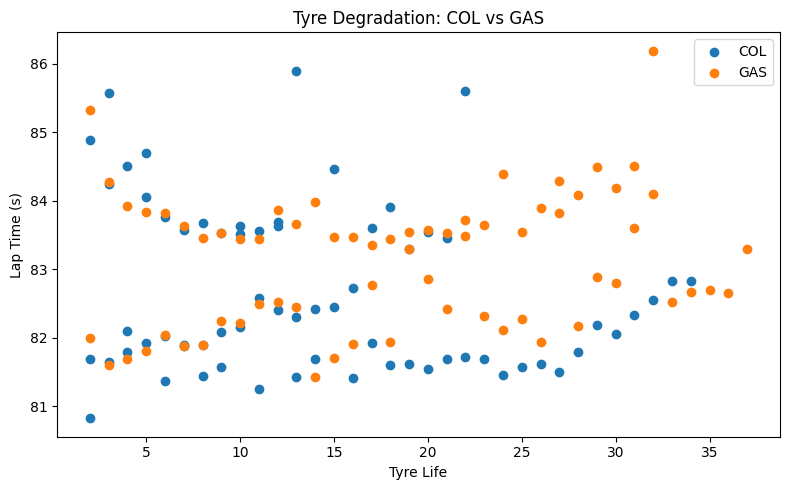

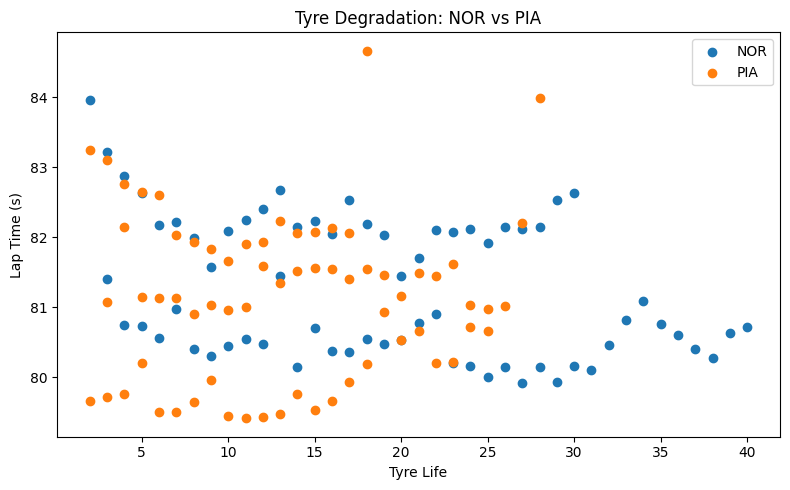

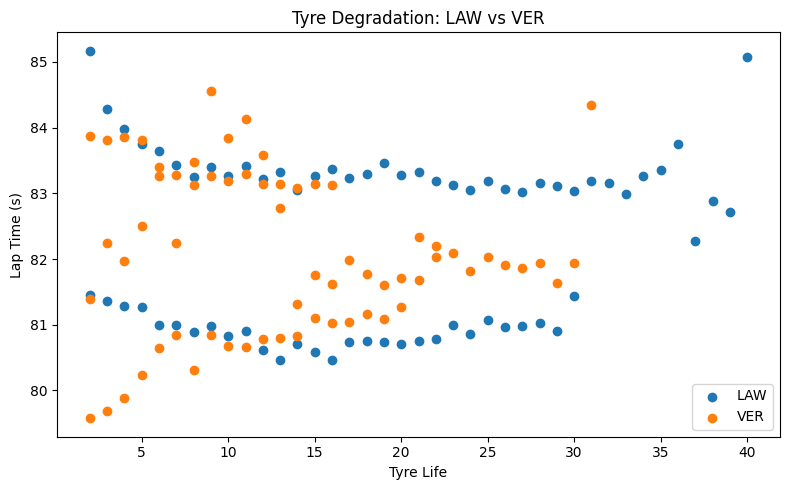

In [119]:
# Measure Tyre Degradation - HUL vs OCO
for pair in DATA.RIVALS:
    slplot.plot_tyre_degradation(top_drivers,pair)

### Insights
- No Red Flag affecting tyre strategy during these stints
- *(Fill in further conclusions on degradation slope per driver)*